# Imported from notebook4619e20cc6.ipynb

Training Folder: /kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training
Testing Folder : /kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Testing
Found 4480 images belonging to 4 classes.
Found 1120 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.

Training CNN without Augmentation
Epoch 1/2
140/140 ━━━━━━━━━━━━━━━━━━━━ 229s 2s/step - accuracy: 0.6940 - loss: 0.7684 - val_accuracy: 0.7991 - val_loss: 0.5266
Epoch 2/2
140/140 ━━━━━━━━━━━━━━━━━━━━ 225s 2s/step - accuracy: 0.8277 - loss: 0.4546 - val_accuracy: 0.8634 - val_loss: 0.3571
Found 4480 images belonging to 4 classes.
Found 1120 images belonging to 4 classes.

Training CNN with Augmentation
Epoch 1/2
140/140 ━━━━━━━━━━━━━━━━━━━━ 259s 2s/step - accuracy: 0.5009 - loss: 1.1328 - val_accuracy: 0.6116 - val_loss: 0.8877
Epoch 2/2
140/140 ━━━━━━━━━━━━━━━━━━━━ 271s 2s/step - accuracy: 0.6246 - loss: 0.8932 - val_accuracy: 0.6187 - val_loss: 0.8829


RQ2 RESULTS
                  

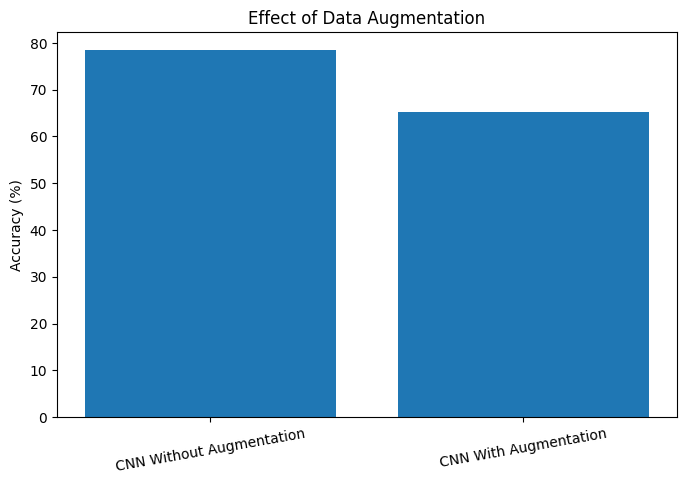


Best Performing Model:
Model           CNN Without Augmentation
Accuracy (%)                      78.375
Name: 0, dtype: object

Research Question 2 Answer:
Data augmentation did not improve the CNN model performance.


In [4]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

# =====================================================
# # =====================================================
# =====================================================
# RQ2: Effect of Data Augmentation on CNN Performance
# =====================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout, Input

# =====================================================
# FIND DATASET
# =====================================================

train_dir = None
test_dir = None

for root, dirs, files in os.walk("/kaggle/input"):
    if os.path.basename(root).lower() == "training":
        train_dir = root
    elif os.path.basename(root).lower() == "testing":
        test_dir = root

print("Training Folder:", train_dir)
print("Testing Folder :", test_dir)

# =====================================================
# WITHOUT DATA AUGMENTATION
# =====================================================

normal_gen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_normal = normal_gen.flow_from_directory(
    train_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_normal = normal_gen.flow_from_directory(
    train_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

test_gen = ImageDataGenerator(rescale=1./255)

test_data = test_gen.flow_from_directory(
    test_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

# =====================================================
# CNN MODEL FUNCTION
# =====================================================

def create_model():

    model = Sequential([
        Input(shape=(224,224,3)),

        Conv2D(32,(3,3),activation='relu'),
        MaxPooling2D(2,2),

        Conv2D(64,(3,3),activation='relu'),
        MaxPooling2D(2,2),

        Conv2D(128,(3,3),activation='relu'),
        MaxPooling2D(2,2),

        Flatten(),

        Dense(128,activation='relu'),
        Dropout(0.5),

        Dense(4,activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

# =====================================================
# MODEL 1 : WITHOUT AUGMENTATION
# =====================================================

print("\nTraining CNN without Augmentation")

cnn1 = create_model()

cnn1.fit(
    train_normal,
    validation_data=val_normal,
    epochs=2,
    verbose=1
)

acc1 = cnn1.evaluate(test_data, verbose=0)[1]

# =====================================================
# WITH DATA AUGMENTATION
# =====================================================

aug_gen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    width_shift_range=0.1,
    height_shift_range=0.1
)

train_aug = aug_gen.flow_from_directory(
    train_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_aug = aug_gen.flow_from_directory(
    train_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

# =====================================================
# MODEL 2 : WITH AUGMENTATION
# =====================================================

print("\nTraining CNN with Augmentation")

cnn2 = create_model()

cnn2.fit(
    train_aug,
    validation_data=val_aug,
    epochs=2,
    verbose=1
)

acc2 = cnn2.evaluate(test_data, verbose=0)[1]

# =====================================================
# RESULTS TABLE
# =====================================================

results = pd.DataFrame({
    "Model":[
        "CNN Without Augmentation",
        "CNN With Augmentation"
    ],
    "Accuracy (%)":[
        acc1*100,
        acc2*100
    ]
})

print("\n")
print("="*50)
print("RQ2 RESULTS")
print("="*50)
print(results)

# =====================================================
# GRAPH
# =====================================================

plt.figure(figsize=(8,5))

plt.bar(
    results["Model"],
    results["Accuracy (%)"]
)

plt.title("Effect of Data Augmentation")
plt.ylabel("Accuracy (%)")
plt.xticks(rotation=10)

plt.show()

# =====================================================
# BEST MODEL
# =====================================================

best = results.loc[
    results["Accuracy (%)"].idxmax()
]

print("\nBest Performing Model:")
print(best)

print("\nResearch Question 2 Answer:")
print(
    f"Data augmentation {'improved' if acc2 > acc1 else 'did not improve'} "
    f"the CNN model performance."
)







   













    


    
   

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

# Imported from notebook079f9b4a37.ipynb

2026-05-31 20:03:30.158589: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780257810.328298      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780257810.376196      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780257810.756882      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780257810.756916      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780257810.756918      58 computation_placer.cc:177] computation placer alr

Found 4480 images belonging to 4 classes.
Found 1120 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.


2026-05-31 20:03:56.063009: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Training Simple CNN
Epoch 1/2
140/140 ━━━━━━━━━━━━━━━━━━━━ 79s 560ms/step - accuracy: 0.7333 - loss: 1.0134 - val_accuracy: 0.8179 - val_loss: 0.4460
Epoch 2/2
140/140 ━━━━━━━━━━━━━━━━━━━━ 75s 536ms/step - accuracy: 0.9315 - loss: 0.2078 - val_accuracy: 0.8598 - val_loss: 0.3835
Training Medium CNN
Epoch 1/2
140/140 ━━━━━━━━━━━━━━━━━━━━ 131s 929ms/step - accuracy: 0.6638 - loss: 0.9366 - val_accuracy: 0.8054 - val_loss: 0.4875
Epoch 2/2
140/140 ━━━━━━━━━━━━━━━━━━━━ 139s 993ms/step - accuracy: 0.8502 - loss: 0.4167 - val_accuracy: 0.8607 - val_loss: 0.3530
Training Deep CNN
Epoch 1/2
140/140 ━━━━━━━━━━━━━━━━━━━━ 195s 1s/step - accuracy: 0.6777 - loss: 0.8207 - val_accuracy: 0.7545 - val_loss: 0.5872
Epoch 2/2
140/140 ━━━━━━━━━━━━━━━━━━━━ 182s 1s/step - accuracy: 0.8455 - loss: 0.4243 - val_accuracy: 0.8304 - val_loss: 0.4287


RQ3 RESULTS
        Model  Accuracy (%)
0  Simple CNN     80.687499
1  Medium CNN     80.500001
2    Deep CNN     77.937502


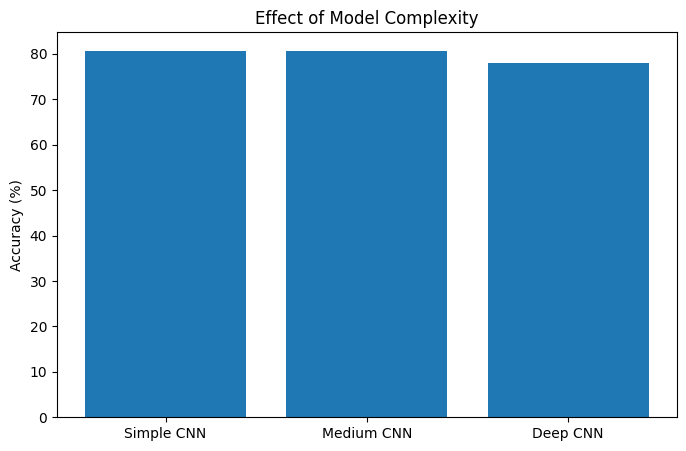


Best Model:
Model           Simple CNN
Accuracy (%)     80.687499
Name: 0, dtype: object

Research Question 3 Answer:
The Simple CNN achieved the highest accuracy of 80.69%.


In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

# =====================================================
# RQ3: Effect of Model Complexity on Performance
# =====================================================

import os
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout, Input

# =====================================================
# FIND DATASET
# =====================================================

train_dir = None
test_dir = None

for root, dirs, files in os.walk("/kaggle/input"):
    if os.path.basename(root).lower() == "training":
        train_dir = root
    elif os.path.basename(root).lower() == "testing":
        test_dir = root

# =====================================================
# DATA LOADING
# =====================================================

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = datagen.flow_from_directory(
    train_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_data = datagen.flow_from_directory(
    train_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

test_data = datagen.flow_from_directory(
    test_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

# =====================================================
# SIMPLE CNN
# =====================================================

simple_cnn = Sequential([
    Input(shape=(224,224,3)),
    Conv2D(32,(3,3),activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(64,activation='relu'),
    Dense(4,activation='softmax')
])

simple_cnn.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Training Simple CNN")

simple_cnn.fit(
    train_data,
    validation_data=val_data,
    epochs=2,
    verbose=1
)

simple_acc = simple_cnn.evaluate(
    test_data,
    verbose=0
)[1]

# =====================================================
# MEDIUM CNN
# =====================================================

medium_cnn = Sequential([
    Input(shape=(224,224,3)),

    Conv2D(32,(3,3),activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(64,(3,3),activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128,activation='relu'),
    Dropout(0.5),

    Dense(4,activation='softmax')
])

medium_cnn.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Training Medium CNN")

medium_cnn.fit(
    train_data,
    validation_data=val_data,
    epochs=2,
    verbose=1
)

medium_acc = medium_cnn.evaluate(
    test_data,
    verbose=0
)[1]

# =====================================================
# DEEP CNN
# =====================================================

deep_cnn = Sequential([
    Input(shape=(224,224,3)),

    Conv2D(32,(3,3),activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(64,(3,3),activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128,(3,3),activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(256,activation='relu'),
    Dropout(0.5),

    Dense(4,activation='softmax')
])

deep_cnn.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Training Deep CNN")

deep_cnn.fit(
    train_data,
    validation_data=val_data,
    epochs=2,
    verbose=1
)

deep_acc = deep_cnn.evaluate(
    test_data,
    verbose=0
)[1]

# =====================================================
# RESULTS TABLE
# =====================================================

results = pd.DataFrame({
    "Model":[
        "Simple CNN",
        "Medium CNN",
        "Deep CNN"
    ],
    "Accuracy (%)":[
        simple_acc*100,
        medium_acc*100,
        deep_acc*100
    ]
})

print("\n")
print("="*50)
print("RQ3 RESULTS")
print("="*50)
print(results)

# =====================================================
# GRAPH
# =====================================================

plt.figure(figsize=(8,5))

plt.bar(
    results["Model"],
    results["Accuracy (%)"]
)

plt.title("Effect of Model Complexity")
plt.ylabel("Accuracy (%)")

plt.show()

# =====================================================
# BEST MODEL
# =====================================================

best_model = results.loc[
    results["Accuracy (%)"].idxmax()
]

print("\nBest Model:")
print(best_model)

print("\nResearch Question 3 Answer:")
print(
    f"The {best_model['Model']} achieved the highest "
    f"accuracy of {best_model['Accuracy (%)']:.2f}%."
)

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

# Imported from notebook3af2a3a6c2.ipynb

2026-06-01 11:32:50.654554: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780313570.949863      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780313571.038899      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780313571.799964      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780313571.800010      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780313571.800013      58 computation_placer.cc:177] computation placer alr

Training Folder: /kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training
Testing Folder : /kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Testing
Found 4480 images belonging to 4 classes.
Found 1120 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.

Training CNN...


2026-06-01 11:33:16.543951: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Epoch 1/2
140/140 ━━━━━━━━━━━━━━━━━━━━ 191s 1s/step - accuracy: 0.6665 - loss: 0.8079 - val_accuracy: 0.7839 - val_loss: 0.5441
Epoch 2/2
140/140 ━━━━━━━━━━━━━━━━━━━━ 180s 1s/step - accuracy: 0.8371 - loss: 0.4543 - val_accuracy: 0.8616 - val_loss: 0.4025

Test Accuracy: 76.69 %
50/50 ━━━━━━━━━━━━━━━━━━━━ 18s 352ms/step


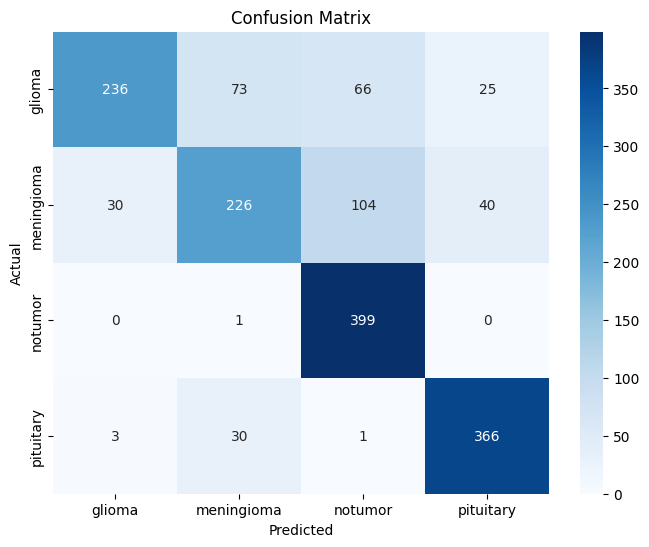


Classification Report
              precision    recall  f1-score      support
glioma         0.877323  0.590000  0.705531   400.000000
meningioma     0.684848  0.565000  0.619178   400.000000
notumor        0.700000  0.997500  0.822680   400.000000
pituitary      0.849188  0.915000  0.880866   400.000000
accuracy       0.766875  0.766875  0.766875     0.766875
macro avg      0.777840  0.766875  0.757064  1600.000000
weighted avg   0.777840  0.766875  0.757064  1600.000000

Total Misclassified Images: 373


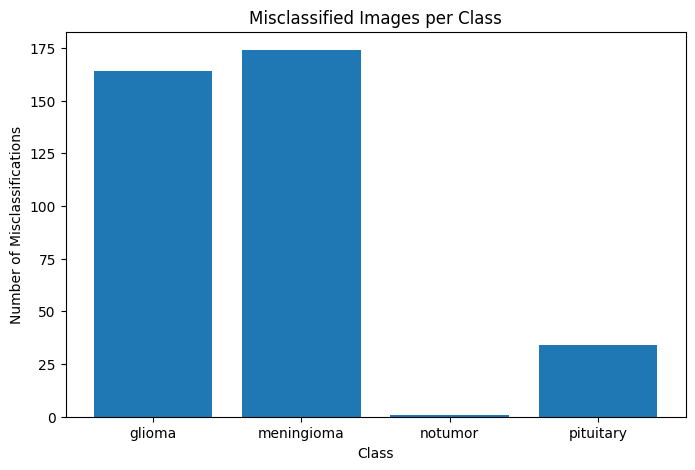


Most Common Misclassification
Actual Class    : meningioma
Predicted Class : notumor
Count           : 104

Results Table
                 Metric   Value
0         Test Accuracy   76.69
1  Misclassified Images  373.00

RQ4 Answer:
The most common classification error occurs when meningioma is predicted as notumor. The confusion matrix and classification report show which tumor classes are most difficult for the CNN to distinguish.


In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

# =====================================================
#
# =====================================================
# RQ4: Misclassification Analysis (Complete Standalone)
# =====================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout, Input

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

# =====================================================
# FIND DATASET
# =====================================================

train_dir = None
test_dir = None

for root, dirs, files in os.walk("/kaggle/input"):
    if os.path.basename(root).lower() == "training":
        train_dir = root
    elif os.path.basename(root).lower() == "testing":
        test_dir = root

print("Training Folder:", train_dir)
print("Testing Folder :", test_dir)

# =====================================================
# DATA GENERATORS
# =====================================================

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = datagen.flow_from_directory(
    train_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_data = datagen.flow_from_directory(
    train_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

test_gen = ImageDataGenerator(rescale=1./255)

test_data = test_gen.flow_from_directory(
    test_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

# =====================================================
# CNN MODEL
# =====================================================

cnn = Sequential([
    Input(shape=(224,224,3)),

    Conv2D(32,(3,3),activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(64,(3,3),activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128,(3,3),activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128,activation='relu'),
    Dropout(0.5),

    Dense(4,activation='softmax')
])

cnn.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("\nTraining CNN...")

cnn.fit(
    train_data,
    validation_data=val_data,
    epochs=2,
    verbose=1
)

# =====================================================
# TEST ACCURACY
# =====================================================

test_acc = cnn.evaluate(
    test_data,
    verbose=0
)[1]

print("\nTest Accuracy:", round(test_acc*100,2), "%")

# =====================================================
# PREDICTIONS
# =====================================================

predictions = cnn.predict(test_data)

y_pred = np.argmax(predictions, axis=1)
y_true = test_data.classes

class_names = list(test_data.class_indices.keys())

# =====================================================
# CONFUSION MATRIX
# =====================================================

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# =====================================================
# CLASSIFICATION REPORT
# =====================================================

report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()

print("\nClassification Report")
print(report_df)

# =====================================================
# SAVE REPORT
# =====================================================

report_df.to_csv(
    "RQ4_Classification_Report.csv"
)

# =====================================================
# MISCLASSIFICATION COUNT
# =====================================================

misclassified = np.where(y_pred != y_true)[0]

print("\nTotal Misclassified Images:", len(misclassified))

# =====================================================
# MISCLASSIFICATION GRAPH
# =====================================================

misclass_count = []

for i in range(len(class_names)):
    misclass_count.append(
        sum(cm[i]) - cm[i][i]
    )

plt.figure(figsize=(8,5))

plt.bar(
    class_names,
    misclass_count
)

plt.title("Misclassified Images per Class")
plt.xlabel("Class")
plt.ylabel("Number of Misclassifications")

plt.show()

# =====================================================
# MOST COMMON CONFUSION
# =====================================================

cm_copy = cm.copy()

np.fill_diagonal(cm_copy, 0)

max_confusion = np.unravel_index(
    np.argmax(cm_copy),
    cm_copy.shape
)

actual_class = class_names[max_confusion[0]]
predicted_class = class_names[max_confusion[1]]

print("\nMost Common Misclassification")
print("Actual Class    :", actual_class)
print("Predicted Class :", predicted_class)
print("Count           :", cm_copy[max_confusion])

# =====================================================
# RESULTS TABLE
# =====================================================

results = pd.DataFrame({
    "Metric":[
        "Test Accuracy",
        "Misclassified Images"
    ],
    "Value":[
        round(test_acc*100,2),
        len(misclassified)
    ]
})

print("\nResults Table")
print(results)

# =====================================================
# FINAL ANSWER
# =====================================================

print("\nRQ4 Answer:")
print(
    f"The most common classification error occurs when "
    f"{actual_class} is predicted as {predicted_class}. "
    f"The confusion matrix and classification report show "
    f"which tumor classes are most difficult for the CNN to distinguish."
)

   



        
    

  
# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

# Imported from notebooka3af1d7844.ipynb

2026-06-01 11:49:44.156247: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780314584.406024      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780314584.476696      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780314585.071996      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780314585.072032      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780314585.072034      58 computation_placer.cc:177] computation placer alr

Training Folder: /kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training
Testing Folder : /kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Testing
Found 4480 images belonging to 4 classes.
Found 1120 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.

Training CNN WITHOUT Dropout


2026-06-01 11:50:07.365977: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Epoch 1/2
140/140 ━━━━━━━━━━━━━━━━━━━━ 163s 1s/step - accuracy: 0.7214 - loss: 0.6943 - val_accuracy: 0.8482 - val_loss: 0.4239
Epoch 2/2
140/140 ━━━━━━━━━━━━━━━━━━━━ 161s 1s/step - accuracy: 0.8958 - loss: 0.2995 - val_accuracy: 0.8973 - val_loss: 0.2889

Training CNN WITH Dropout
Epoch 1/2
140/140 ━━━━━━━━━━━━━━━━━━━━ 162s 1s/step - accuracy: 0.6440 - loss: 0.8592 - val_accuracy: 0.7482 - val_loss: 0.6216
Epoch 2/2
140/140 ━━━━━━━━━━━━━━━━━━━━ 202s 1s/step - accuracy: 0.7971 - loss: 0.5178 - val_accuracy: 0.8188 - val_loss: 0.4806


RQ5 RESULTS
                 Model  Accuracy (%)
0  CNN Without Dropout       80.7500
1     CNN With Dropout       72.9375


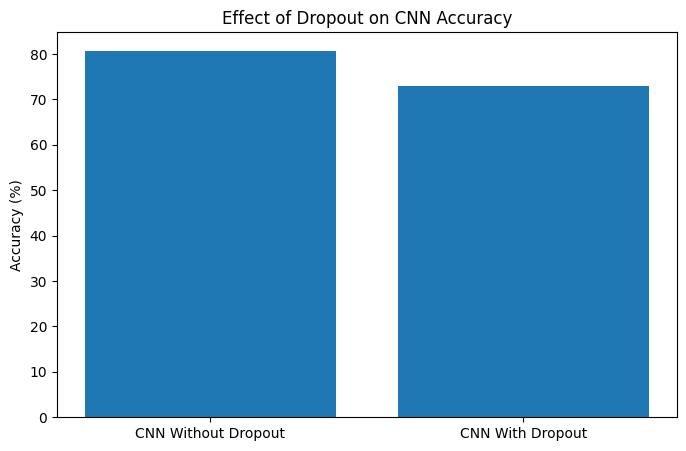

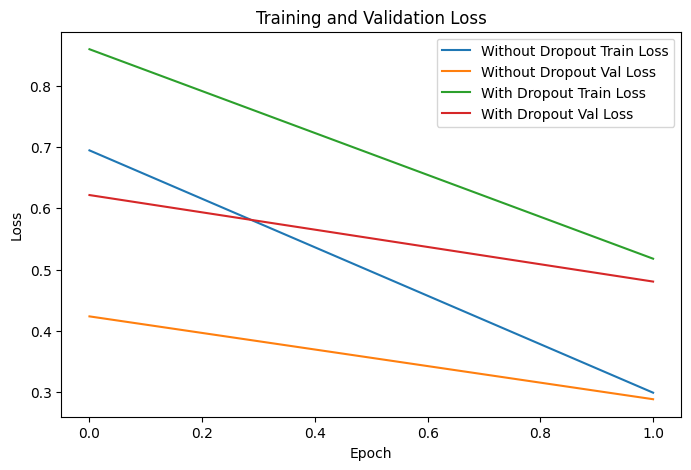


Best Model:
Model           CNN Without Dropout
Accuracy (%)                  80.75
Name: 0, dtype: object

Research Question 5 Answer:
The model 'CNN Without Dropout' achieved the highest accuracy of 80.75%.


In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

# =====================================================
# RQ5: Effect of Dropout on CNN Performance
# =====================================================

import os
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout, Input

# =====================================================
# FIND DATASET
# =====================================================

train_dir = None
test_dir = None

for root, dirs, files in os.walk("/kaggle/input"):
    if os.path.basename(root).lower() == "training":
        train_dir = root
    elif os.path.basename(root).lower() == "testing":
        test_dir = root

print("Training Folder:", train_dir)
print("Testing Folder :", test_dir)

# =====================================================
# DATA LOADER
# =====================================================

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = datagen.flow_from_directory(
    train_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_data = datagen.flow_from_directory(
    train_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

test_data = datagen.flow_from_directory(
    test_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

# =====================================================
# CNN WITHOUT DROPOUT
# =====================================================

cnn_no_dropout = Sequential([
    Input(shape=(224,224,3)),

    Conv2D(32,(3,3),activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(64,(3,3),activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128,(3,3),activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128,activation='relu'),

    Dense(4,activation='softmax')
])

cnn_no_dropout.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("\nTraining CNN WITHOUT Dropout")

history1 = cnn_no_dropout.fit(
    train_data,
    validation_data=val_data,
    epochs=2,
    verbose=1
)

acc1 = cnn_no_dropout.evaluate(
    test_data,
    verbose=0
)[1]

# =====================================================
# CNN WITH DROPOUT
# =====================================================

cnn_dropout = Sequential([
    Input(shape=(224,224,3)),

    Conv2D(32,(3,3),activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(64,(3,3),activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128,(3,3),activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128,activation='relu'),

    Dropout(0.5),

    Dense(4,activation='softmax')
])

cnn_dropout.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("\nTraining CNN WITH Dropout")

history2 = cnn_dropout.fit(
    train_data,
    validation_data=val_data,
    epochs=2,
    verbose=1
)

acc2 = cnn_dropout.evaluate(
    test_data,
    verbose=0
)[1]

# =====================================================
# RESULTS TABLE
# =====================================================

results = pd.DataFrame({
    "Model":[
        "CNN Without Dropout",
        "CNN With Dropout"
    ],
    "Accuracy (%)":[
        acc1*100,
        acc2*100
    ]
})

print("\n")
print("="*50)
print("RQ5 RESULTS")
print("="*50)
print(results)

# =====================================================
# ACCURACY BAR GRAPH
# =====================================================

plt.figure(figsize=(8,5))

plt.bar(
    results["Model"],
    results["Accuracy (%)"]
)

plt.title("Effect of Dropout on CNN Accuracy")
plt.ylabel("Accuracy (%)")

plt.show()

# =====================================================
# TRAINING VS VALIDATION LOSS
# =====================================================

plt.figure(figsize=(8,5))

plt.plot(
    history1.history['loss'],
    label='Without Dropout Train Loss'
)

plt.plot(
    history1.history['val_loss'],
    label='Without Dropout Val Loss'
)

plt.plot(
    history2.history['loss'],
    label='With Dropout Train Loss'
)

plt.plot(
    history2.history['val_loss'],
    label='With Dropout Val Loss'
)

plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()

plt.show()

# =====================================================
# SAVE RESULTS
# =====================================================

results.to_csv(
    "RQ5_Dropout_Results.csv",
    index=False
)

# =====================================================
# BEST MODEL
# =====================================================

best_model = results.loc[
    results["Accuracy (%)"].idxmax()
]

print("\nBest Model:")
print(best_model)

print("\nResearch Question 5 Answer:")
print(
    f"The model '{best_model['Model']}' achieved the "
    f"highest accuracy of "
    f"{best_model['Accuracy (%)']:.2f}%."
)

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [ ]:
import matplotlib.pyplot as plt

# Training vs Validation Accuracy
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Training vs Validation Loss
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()
